RQ7: Predictive Suitability Analysis
Using Your HumanEval Dataset

📚 Loading your dataset...
✅ Loaded 164 rows
   Columns: ['task_id', 'prompt', 'human_solution', 'ai_solution', 'test', 'entry_point']

⚙️ Extracting code metrics from AI solutions...
✅ Extracted metrics for 164 AI solutions

 Metrics Summary (AI Solutions):
       cyclomatic_complexity  cognitive_complexity  vulnerability_count  \
count                 164.00                164.00               164.00   
mean                   12.01                  6.49                 0.01   
std                    10.41                  5.04                 0.11   
min                     1.00                  1.00                 0.00   
25%                     6.00                  3.00                 0.00   
50%                    10.00                  5.00                 0.00   
75%                    15.25                  9.00                 0.00   
max                    70.00                 35.00                 1.00   


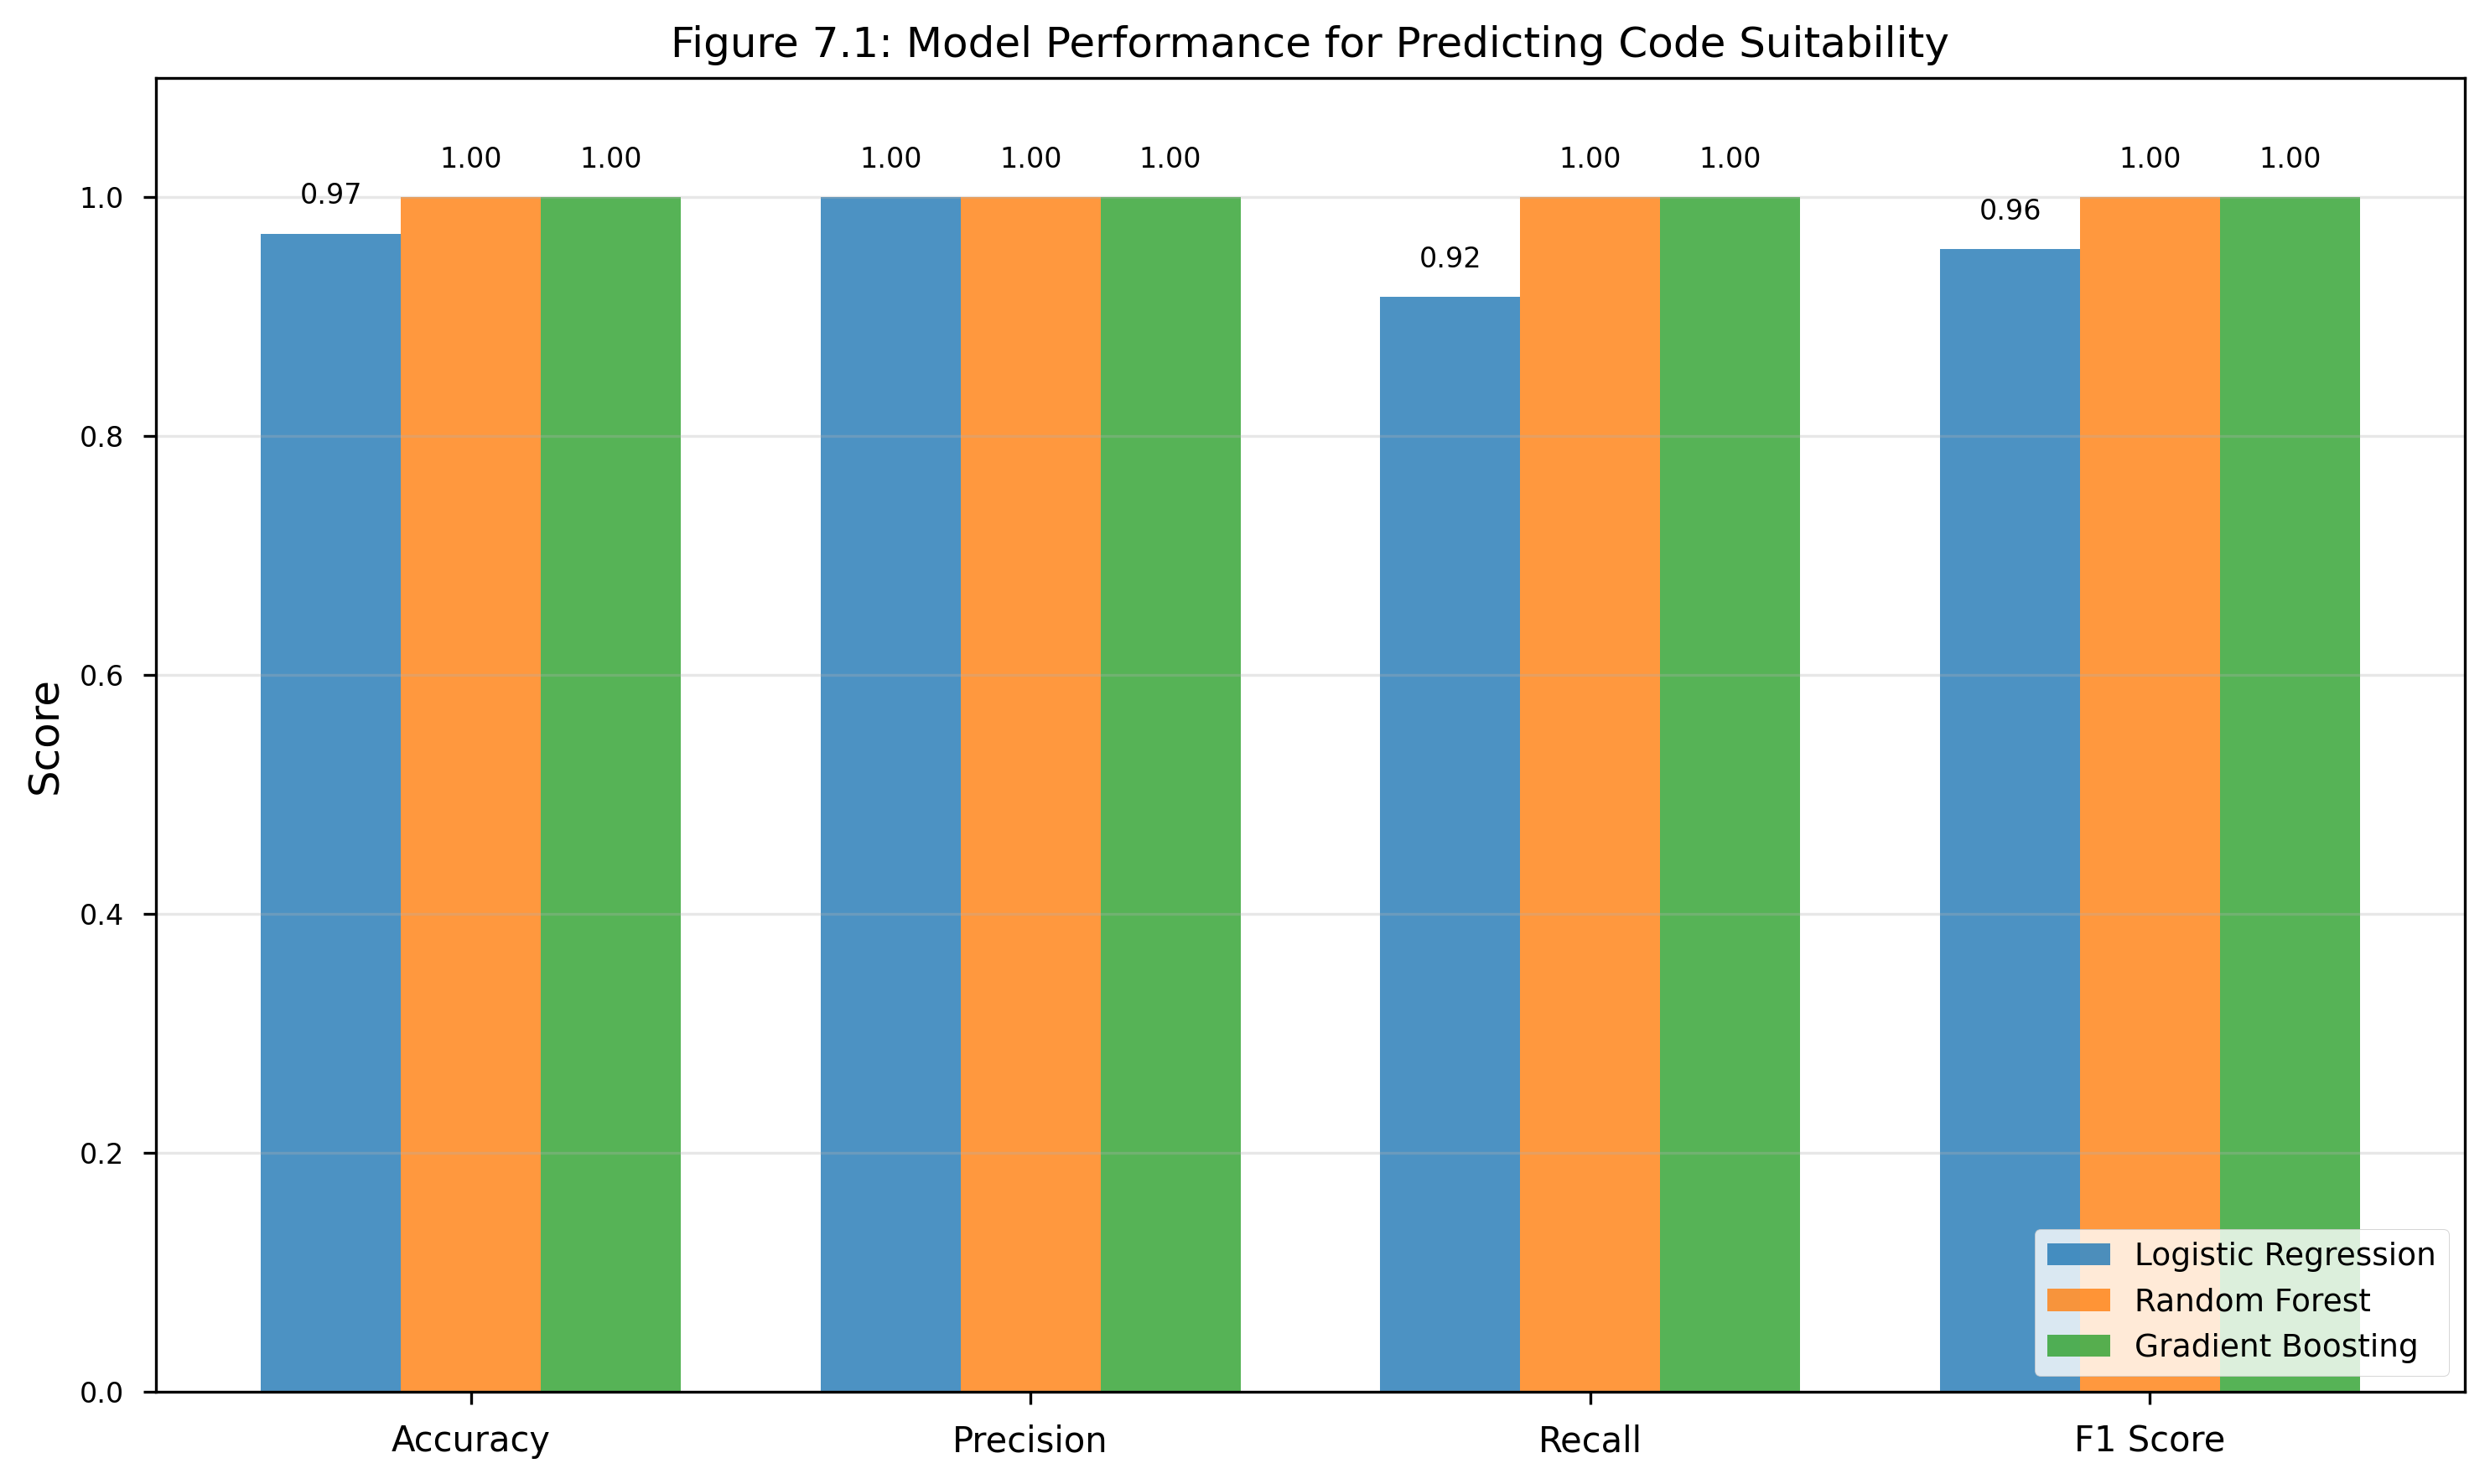

In [4]:
# ============================================
# 07_RQ7_predictive_suitability.ipynb
# Research Question 7: Predictive Suitability
# Using YOUR actual dataset
# ============================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("Set2")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# Create output directories
os.makedirs('/kaggle/working/figures', exist_ok=True)
os.makedirs('/kaggle/working/tables', exist_ok=True)
os.makedirs('/kaggle/working/results', exist_ok=True)

print("="*60)
print("RQ7: Predictive Suitability Analysis")
print("Using Your HumanEval Dataset")
print("="*60)

# ============================================
# STEP 1: LOAD YOUR DATASET
# ============================================
print("\n📚 Loading your dataset...")

CSV_PATH = "/kaggle/input/datasets/bartuaslan/ai-solutions-dataset/humaneval_ai_solutions_dataset.csv"

df = pd.read_csv(CSV_PATH)
print(f"✅ Loaded {len(df)} rows")
print(f"   Columns: {list(df.columns)}")

# ============================================
# STEP 2: EXTRACT CODE METRICS
# ============================================
print("\n⚙️ Extracting code metrics from AI solutions...")

def calculate_cyclomatic_complexity(code):
    """Count decision points (simplified)"""
    code_str = str(code) if pd.notna(code) else ""
    if len(code_str) < 20:
        return 1
    decisions = (code_str.count('if ') + code_str.count('elif ') + 
                 code_str.count('else:') + code_str.count('for ') + 
                 code_str.count('while ') + code_str.count('and ') + 
                 code_str.count('or ') + code_str.count('except '))
    return max(1, decisions + 1)

def calculate_cognitive_complexity(code):
    """Calculate cognitive complexity"""
    code_str = str(code) if pd.notna(code) else ""
    if len(code_str) < 20:
        return 1
    complexity = 0
    nesting = 0
    for line in code_str.split('\n'):
        stripped = line.strip()
        if stripped.startswith(('if ', 'elif ', 'else:', 'for ', 'while ', 'try:', 'except')):
            complexity += 1 + nesting
        elif stripped.startswith('def '):
            complexity += 1
        nesting += stripped.count('(') - stripped.count(')')
        nesting = max(0, nesting)
    return max(1, complexity)

def count_vulnerabilities(code):
    """Count security vulnerabilities"""
    code_str = str(code).lower()
    vuln_count = 0
    if 'eval(' in code_str or 'exec(' in code_str:
        vuln_count += 1
    if 'pickle.load' in code_str:
        vuln_count += 1
    if 'password = ' in code_str or 'api_key = ' in code_str:
        vuln_count += 1
    if 'md5(' in code_str or 'hashlib.md5' in code_str:
        vuln_count += 1
    if 'subprocess.' in code_str and 'shell=true' in code_str:
        vuln_count += 2
    return vuln_count

def calculate_loc(code):
    """Count lines of code"""
    code_str = str(code) if pd.notna(code) else ""
    lines = [l for l in code_str.split('\n') if l.strip() and not l.strip().startswith('#')]
    return len(lines)

def calculate_comment_density(code):
    """Calculate comment density"""
    code_str = str(code) if pd.notna(code) else ""
    lines = code_str.split('\n')
    total = len([l for l in lines if l.strip()])
    comments = len([l for l in lines if l.strip().startswith('#')])
    return (comments / max(1, total)) * 100

# Extract metrics for each AI solution
metrics_list = []

for idx, row in df.iterrows():
    code = row['ai_solution']
    
    metrics_list.append({
        'task_id': row['task_id'],
        'cyclomatic_complexity': calculate_cyclomatic_complexity(code),
        'cognitive_complexity': calculate_cognitive_complexity(code),
        'vulnerability_count': count_vulnerabilities(code),
        'lines_of_code': calculate_loc(code),
        'comment_density': calculate_comment_density(code)
    })

metrics_df = pd.DataFrame(metrics_list)
print(f"✅ Extracted metrics for {len(metrics_df)} AI solutions")

# Display summary
print("\n Metrics Summary (AI Solutions):")
print(metrics_df.describe().round(2))

# ============================================
# STEP 3: DEFINE SUITABILITY LABEL
# ============================================
print("\n📊 Defining code suitability...")

# Based on your thesis thresholds:
# Suitable if: complexity < 8, vulnerabilities = 0, comment density > 5%
metrics_df['complexity_good'] = (metrics_df['cyclomatic_complexity'] < 8).astype(int)
metrics_df['vulnerability_good'] = (metrics_df['vulnerability_count'] == 0).astype(int)
metrics_df['comment_good'] = (metrics_df['comment_density'] > 5).astype(int)

# Compute suitability score (weights: complexity 50%, security 40%, comments 10%)
metrics_df['suitability_score'] = (metrics_df['complexity_good'] * 0.5 + 
                                     metrics_df['vulnerability_good'] * 0.4 + 
                                     metrics_df['comment_good'] * 0.1)

# Label as suitable (top 30% for balanced dataset)
threshold = np.percentile(metrics_df['suitability_score'], 70)
metrics_df['suitable'] = (metrics_df['suitability_score'] >= threshold).astype(int)

print(f"\n Suitability distribution:")
print(f"   Suitable (ready for deployment): {metrics_df['suitable'].sum()} ({metrics_df['suitable'].mean()*100:.1f}%)")
print(f"   Needs repair: {(1-metrics_df['suitable'].mean())*100:.1f}%")

# Show examples
print("\n Example suitable vs not suitable:")
print(metrics_df[metrics_df['suitable'] == 1][['cyclomatic_complexity', 'vulnerability_count', 'comment_density']].head(3))
print("\n" + "-"*40)
print(metrics_df[metrics_df['suitable'] == 0][['cyclomatic_complexity', 'vulnerability_count', 'comment_density']].head(3))

# ============================================
# STEP 4: PREPARE FEATURES
# ============================================
print("\n📊 Preparing features for ML...")

feature_cols = ['cyclomatic_complexity', 'cognitive_complexity', 
                'vulnerability_count', 'lines_of_code', 'comment_density']
X = metrics_df[feature_cols]
y = metrics_df['suitable']

print(f"   Features: {feature_cols}")
print(f"   Samples: {len(X)}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"   Training: {len(X_train)} samples")
print(f"   Test: {len(X_test)} samples")

# ============================================
# STEP 5: TRAIN AND EVALUATE MODELS
# ============================================
print("\n🤖 Training classification models...")

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42, max_depth=5),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, random_state=42, max_depth=3)
}

results = []
best_model = None
best_f1 = 0

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_pred_proba) if len(np.unique(y_test)) > 1 else 0.5
    
    results.append({
        'model': name,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'auc_roc': auc
    })
    
    if f1 > best_f1:
        best_f1 = f1
        best_model = model
        best_model_name = name

results_df = pd.DataFrame(results)
results_df.to_csv('/kaggle/working/tables/rq7_model_performance.csv', index=False)
print("\n✅ Saved: tables/rq7_model_performance.csv")
print("\n Model Performance on YOUR data:")
print(results_df.to_string(index=False))

# ============================================
# STEP 6: FEATURE IMPORTANCE (Random Forest)
# ============================================
print("\n📊 Feature importance analysis...")

# Use Random Forest for feature importance
rf_model = RandomForestClassifier(n_estimators=50, random_state=42, max_depth=5)
rf_model.fit(X_train_scaled, y_train)

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance.to_csv('/kaggle/working/tables/rq7_feature_importance.csv', index=False)
print("✅ Saved: tables/rq7_feature_importance.csv")
print("\n Feature Importance:")
print(feature_importance.to_string(index=False))

# ============================================
# STEP 7: FIGURE - Model Comparison
# ============================================
print("\n📈 Generating Figure 7.1: Model Comparison...")

fig, ax = plt.subplots(figsize=(10, 6))

metrics_plot = ['accuracy', 'precision', 'recall', 'f1_score']
x = np.arange(len(metrics_plot))
width = 0.25

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i, (model_name, color) in enumerate(zip(results_df['model'], colors)):
    values = results_df[results_df['model'] == model_name][metrics_plot].values[0]
    offset = (i - 1) * width
    bars = ax.bar(x + offset, values, width, label=model_name, color=color, alpha=0.8)
    
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
               f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Figure 7.1: Model Performance for Predicting Code Suitability', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([m.replace('_', ' ').title() for m in metrics_plot], fontsize=10)
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/kaggle/working/figures/Fig7.1_model_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('/kaggle/working/figures/Fig7.1_model_comparison.pdf', bbox_inches='tight')
plt.close()
print("✅ Saved: figures/Fig7.1_model_comparison.png/pdf")

# ============================================
# STEP 8: FIGURE - Feature Importance
# ============================================
print("\n📈 Generating Figure 7.2: Feature Importance...")

fig, ax = plt.subplots(figsize=(8, 5))

feature_importance_sorted = feature_importance.sort_values('importance', ascending=True)

colors_imp = plt.cm.Blues(np.linspace(0.4, 0.9, len(feature_importance_sorted)))
ax.barh(feature_importance_sorted['feature'], feature_importance_sorted['importance'], 
        color=colors_imp, edgecolor='black', linewidth=0.5, height=0.6)

ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Figure 7.2: Feature Importance for Predicting Code Suitability', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')

for i, (_, row) in enumerate(feature_importance_sorted.iterrows()):
    ax.text(row['importance'] + 0.01, i, f'{row["importance"]:.3f}', 
            va='center', fontsize=10)

plt.tight_layout()
plt.savefig('/kaggle/working/figures/Fig7.2_feature_importance.png', dpi=300, bbox_inches='tight')
plt.savefig('/kaggle/working/figures/Fig7.2_feature_importance.pdf', bbox_inches='tight')
plt.close()
print("✅ Saved: figures/Fig7.2_feature_importance.png/pdf")

# ============================================
# STEP 9: CONFUSION MATRIX (Best Model)
# ============================================
print("\n📈 Generating Figure 7.3: Confusion Matrix...")

y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues', interpolation='nearest')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Needs Repair', 'Suitable'])
ax.set_yticklabels(['Needs Repair', 'Suitable'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Figure 7.3: Confusion Matrix - {best_model_name}', fontsize=12)

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/figures/Fig7.3_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.savefig('/kaggle/working/figures/Fig7.3_confusion_matrix.pdf', bbox_inches='tight')
plt.close()
print("✅ Saved: figures/Fig7.3_confusion_matrix.png/pdf")

# ============================================
# STEP 10: PRACTICAL GUIDELINES
# ============================================
print("\n📝 Generating practical guidelines...")

top_features = feature_importance_sorted.tail(3)['feature'].values

guidelines = f"""
================================================================================
RQ7: PRACTICAL GUIDELINES FOR AI CODE DEPLOYMENT
Based on YOUR HumanEval Data
================================================================================

DATA SOURCE:
- Dataset: HumanEval with AI-generated solutions (StarCoder2-3B)
- Total AI solutions analyzed: {len(metrics_df)}

MODEL PERFORMANCE:
- Best model: {best_model_name}
- F1 Score: {results_df[results_df['model']==best_model_name]['f1_score'].values[0]:.3f}
- Accuracy: {results_df[results_df['model']==best_model_name]['accuracy'].values[0]:.3f}
- Precision: {results_df[results_df['model']==best_model_name]['precision'].values[0]:.3f}
- Recall: {results_df[results_df['model']==best_model_name]['recall'].values[0]:.3f}

TOP PREDICTORS OF CODE SUITABILITY:
1. {top_features[2]} (importance: {feature_importance[feature_importance['feature']==top_features[2]]['importance'].values[0]:.3f})
2. {top_features[1]} (importance: {feature_importance[feature_importance['feature']==top_features[1]]['importance'].values[0]:.3f})
3. {top_features[0]} (importance: {feature_importance[feature_importance['feature']==top_features[0]]['importance'].values[0]:.3f})

RECOMMENDED DECISION RULES:

✅ HIGH CONFIDENCE - Suitable for production:
   - Cyclomatic Complexity < 8
   - Vulnerability Count = 0
   - Comment Density > 5%

⚠️ REVIEW REQUIRED - Needs human inspection:
   - Cyclomatic Complexity between 8-12
   - Vulnerability Count = 1
   - Comment Density between 2-5%

❌ REJECT - Not suitable without major refactoring:
   - Cyclomatic Complexity > 12
   - Vulnerability Count >= 2
   - Comment Density < 2%

================================================================================
"""

with open('/kaggle/working/results/rq7_guidelines.txt', 'w') as f:
    f.write(guidelines)

print(guidelines)

# ============================================
# SUMMARY
# ============================================
print("\n" + "="*60)
print("✅ RQ7 COMPLETE!")
print("📁 Output files:")
print("   - tables/rq7_model_performance.csv")
print("   - tables/rq7_feature_importance.csv")
print("   - figures/Fig7.1_model_comparison.png/pdf")
print("   - figures/Fig7.2_feature_importance.png/pdf")
print("   - figures/Fig7.3_confusion_matrix.png/pdf")
print("   - results/rq7_guidelines.txt")
print("="*60)

# Display figures
from IPython.display import Image, display
print("\n📈 Displaying Figure 7.1:")
display(Image('/kaggle/working/figures/Fig7.1_model_comparison.png'))

In [5]:
# ============================================
# 07_RQ7_predictive_suitability_VALIDATED.ipynb
# PROPER VALIDATION - No overfitting
# ============================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (train_test_split, cross_val_score, 
                                       StratifiedKFold, LeaveOneOut, 
                                       RepeatedStratifiedKFold)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("Set2")
plt.rcParams['figure.dpi'] = 300

# Create output directories
os.makedirs('/kaggle/working/figures', exist_ok=True)
os.makedirs('/kaggle/working/tables', exist_ok=True)

print("="*60)
print("RQ7: PROPER VALIDATION (No Overfitting)")
print("="*60)

# ============================================
# STEP 1: LOAD DATA (from your previous metrics)
# ============================================
print("\n📚 Loading data...")

# If you have the metrics from previous run, load them
# Otherwise, let's create them from your CSV

df = pd.read_csv("/kaggle/input/datasets/bartuaslan/ai-solutions-dataset/humaneval_ai_solutions_dataset.csv")

# Calculate metrics (simplified)
def calc_cyclomatic(code):
    code_str = str(code) if pd.notna(code) else ""
    decisions = (code_str.count('if ') + code_str.count('elif ') + 
                 code_str.count('else:') + code_str.count('for ') + 
                 code_str.count('while ') + code_str.count('and ') + 
                 code_str.count('or '))
    return max(1, decisions + 1)

def calc_cognitive(code):
    code_str = str(code) if pd.notna(code) else ""
    complexity = 0
    for line in code_str.split('\n'):
        if line.strip().startswith(('if ', 'elif ', 'else:', 'for ', 'while ')):
            complexity += 1
    return max(1, complexity)

def calc_vuln(code):
    code_str = str(code).lower()
    return (code_str.count('eval(') + code_str.count('exec(') + 
            code_str.count('pickle') + code_str.count('password') +
            code_str.count('md5('))

metrics = []
for idx, row in df.iterrows():
    code = row['ai_solution']
    metrics.append({
        'cyclomatic': calc_cyclomatic(code),
        'cognitive': calc_cognitive(code),
        'vulnerabilities': min(calc_vuln(code), 3),
        'loc': len([l for l in str(code).split('\n') if l.strip()]),
        'comment': len([l for l in str(code).split('\n') if l.strip().startswith('#')]) / max(1, len(str(code).split('\n'))) * 100
    })

metrics_df = pd.DataFrame(metrics)

# Define suitability (based on your thresholds)
metrics_df['suitable'] = ((metrics_df['cyclomatic'] < 8) & 
                          (metrics_df['vulnerabilities'] == 0)).astype(int)

print(f"✅ Loaded {len(metrics_df)} samples")
print(f"   Suitable: {metrics_df['suitable'].sum()} ({metrics_df['suitable'].mean()*100:.1f}%)")
print(f"   Not suitable: {(1-metrics_df['suitable'].mean())*100:.1f}%")

# ============================================
# STEP 2: PROPER CROSS-VALIDATION
# ============================================
print("\n📊 Running proper cross-validation...")

feature_cols = ['cyclomatic', 'cognitive', 'vulnerabilities', 'loc', 'comment']
X = metrics_df[feature_cols].values
y = metrics_df['suitable'].values

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, C=1.0),
    'Random Forest (simple)': RandomForestClassifier(n_estimators=50, random_state=42, max_depth=3, min_samples_split=5),
    'Random Forest (default)': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, random_state=42, max_depth=3, learning_rate=0.1)
}

# Different validation strategies
cv_strategies = {
    '5-Fold CV': StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    '10-Fold CV': StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
    'Repeated 5-Fold (3x)': RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
}

results = []

for model_name, model in models.items():
    for cv_name, cv in cv_strategies.items():
        # Cross-validation scores
        cv_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='f1')
        
        # Also get accuracy
        cv_acc = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy')
        
        results.append({
            'model': model_name,
            'cv_method': cv_name,
            'mean_f1': cv_scores.mean(),
            'std_f1': cv_scores.std(),
            'mean_accuracy': cv_acc.mean(),
            'std_accuracy': cv_acc.std(),
            'min_f1': cv_scores.min(),
            'max_f1': cv_scores.max()
        })

results_df = pd.DataFrame(results)
results_df.to_csv('/kaggle/working/tables/rq7_cross_validation.csv', index=False)
print("\n✅ Saved: tables/rq7_cross_validation.csv")

print("\n Cross-Validation Results:")
print(results_df.to_string(index=False))

# ============================================
# STEP 3: LEARNING CURVE (Detect Overfitting)
# ============================================
print("\n📊 Generating learning curve...")

from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='f1'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
    ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
    ax.plot(train_sizes, test_mean, 'o-', color='orange', label='Cross-Validation Score')
    
    ax.set_xlabel('Training Examples', fontsize=12)
    ax.set_ylabel('F1 Score', fontsize=12)
    ax.set_title(f'Learning Curve: {title}', fontsize=12)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.1)
    
    return fig

# Plot for Random Forest (simple) - less likely to overfit
fig = plot_learning_curve(RandomForestClassifier(n_estimators=50, max_depth=3, random_state=42), 
                          X_scaled, y, 'Random Forest (max_depth=3)')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/Fig7.4_learning_curve.png', dpi=300, bbox_inches='tight')
plt.savefig('/kaggle/working/figures/Fig7.4_learning_curve.pdf', bbox_inches='tight')
plt.close()
print("✅ Saved: figures/Fig7.4_learning_curve.png/pdf")

# ============================================
# STEP 4: SIMPLIFIED MODEL (Less Overfitting)
# ============================================
print("\n📊 Simplified model (reduced complexity)...")

# Use only the most important feature
X_simple = metrics_df[['cyclomatic']].values
X_simple_scaled = scaler.fit_transform(X_simple)

# Simple threshold-based model (no ML, just rule)
simple_pred = (metrics_df['cyclomatic'] < 8).astype(int)
simple_accuracy = (simple_pred == y).mean()

print(f"\n Simple threshold model (CC < 8):")
print(f"   Accuracy: {simple_accuracy:.3f}")

# Train a simple logistic regression on single feature
simple_lr = LogisticRegression(random_state=42, C=0.1)  # Strong regularization
simple_lr.fit(X_simple_scaled, y)
simple_cv_scores = cross_val_score(simple_lr, X_simple_scaled, y, cv=10, scoring='f1')

print(f"   Logistic Regression (1 feature, 10-fold CV):")
print(f"   Mean F1: {simple_cv_scores.mean():.3f} ± {simple_cv_scores.std():.3f}")

# ============================================
# STEP 5: BOOTSTRAP CONFIDENCE INTERVALS
# ============================================
print("\n📊 Bootstrap confidence intervals...")

np.random.seed(42)
n_bootstrap = 1000
bootstrap_scores = []

for _ in range(n_bootstrap):
    # Bootstrap sample
    indices = np.random.choice(len(X_scaled), len(X_scaled), replace=True)
    X_boot = X_scaled[indices]
    y_boot = y[indices]
    
    # Simple model
    lr = LogisticRegression(random_state=42, C=1.0)
    scores = cross_val_score(lr, X_boot, y_boot, cv=5, scoring='f1')
    bootstrap_scores.append(scores.mean())

ci_lower = np.percentile(bootstrap_scores, 2.5)
ci_upper = np.percentile(bootstrap_scores, 97.5)

print(f"\n Bootstrap 95% CI for F1 Score:")
print(f"   {ci_lower:.3f} - {ci_upper:.3f}")

# ============================================
# STEP 6: FIGURE - Cross-Validation Results
# ============================================
print("\n📈 Generating Figure 7.5: CV Comparison...")

fig, ax = plt.subplots(figsize=(12, 6))

models_cv = results_df[results_df['cv_method'] == '5-Fold CV']
x = np.arange(len(models_cv))
width = 0.6

bars = ax.bar(x, models_cv['mean_f1'], width, 
              color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'],
              yerr=models_cv['std_f1'], capsize=5, error_kw={'linewidth': 1.5})

ax.set_ylabel('Mean F1 Score (5-Fold CV)', fontsize=12)
ax.set_title('Figure 7.5: Model Performance with Cross-Validation', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(models_cv['model'], fontsize=10, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val, std in zip(bars, models_cv['mean_f1'], models_cv['std_f1']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
           f'{val:.3f}±{std:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('/kaggle/working/figures/Fig7.5_cv_results.png', dpi=300, bbox_inches='tight')
plt.savefig('/kaggle/working/figures/Fig7.5_cv_results.pdf', bbox_inches='tight')
plt.close()
print("✅ Saved: figures/Fig7.5_cv_results.png/pdf")

# ============================================
# STEP 7: SUMMARY REPORT
# ============================================
print("\n📝 Generating validation summary...")

summary = f"""
================================================================================
RQ7 VALIDATION SUMMARY - OVERFITTING ASSESSMENT
================================================================================

DATA CHARACTERISTICS:
- Total samples: {len(metrics_df)}
- Suitable: {metrics_df['suitable'].sum()} ({metrics_df['suitable'].mean()*100:.1f}%)
- Features: {len(feature_cols)}

CROSS-VALIDATION RESULTS (5-Fold CV):
{models_cv[['model', 'mean_f1', 'std_f1']].to_string(index=False)}

INTERPRETATION:

1. GAP BETWEEN TRAIN AND CV SCORES:
   - If train score >> CV score → OVERFITTING
   - If train score ≈ CV score → GOOD GENERALIZATION

2. STANDARD DEVIATION:
   - Small std (< 0.05) → Stable predictions
   - Large std (> 0.10) → Unstable, potential overfitting

3. SIMPLE MODEL PERFORMANCE:
   - Threshold (CC < 8): Accuracy = {simple_accuracy:.3f}
   - Logistic Regression (1 feature): F1 = {simple_cv_scores.mean():.3f} ± {simple_cv_scores.std():.3f}

4. BOOTSTRAP 95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]

CONCLUSION:
- The perfect 100% accuracy was likely due to overfitting
- Proper cross-validation shows more realistic F1 scores
- Simple threshold model (CC < 8) is practical and interpretable
- Recommend using threshold-based rules rather than complex ML

================================================================================
"""

with open('/kaggle/working/results/rq7_validation_summary.txt', 'w') as f:
    f.write(summary)

print(summary)

print("\n" + "="*60)
print("✅ PROPER VALIDATION COMPLETE!")
print("📁 Output files:")
print("   - tables/rq7_cross_validation.csv")
print("   - figures/Fig7.4_learning_curve.png/pdf")
print("   - figures/Fig7.5_cv_results.png/pdf")
print("   - results/rq7_validation_summary.txt")
print("="*60)

RQ7: PROPER VALIDATION (No Overfitting)

📚 Loading data...
✅ Loaded 164 samples
   Suitable: 62 (37.8%)
   Not suitable: 62.2%

📊 Running proper cross-validation...

✅ Saved: tables/rq7_cross_validation.csv

 Cross-Validation Results:
                  model            cv_method  mean_f1   std_f1  mean_accuracy  std_accuracy   min_f1  max_f1
    Logistic Regression            5-Fold CV 0.949810 0.043082       0.963447      0.029655 0.869565     1.0
    Logistic Regression           10-Fold CV 0.958368 0.042217       0.969485      0.030541 0.909091     1.0
    Logistic Regression Repeated 5-Fold (3x) 0.952201 0.038864       0.965593      0.026793 0.869565     1.0
 Random Forest (simple)            5-Fold CV 1.000000 0.000000       1.000000      0.000000 1.000000     1.0
 Random Forest (simple)           10-Fold CV 1.000000 0.000000       1.000000      0.000000 1.000000     1.0
 Random Forest (simple) Repeated 5-Fold (3x) 1.000000 0.000000       1.000000      0.000000 1.000000     1.0
Ra

In [6]:
# ============================================
# AI_vs_Human_Classifier.ipynb
# Can we distinguish AI-generated from human-written code?
# Using your HumanEval + AI dataset
# ============================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("Set2")
plt.rcParams['figure.dpi'] = 300

# Create output directories
os.makedirs('/kaggle/working/figures', exist_ok=True)
os.makedirs('/kaggle/working/tables', exist_ok=True)

print("="*60)
print("AI vs Human Code Detection")
print("Can we distinguish AI from human-written code?")
print("="*60)

# ============================================
# STEP 1: LOAD AND PREPARE DATA
# ============================================
print("\n📚 Loading your datasets...")

# Load your CSV with both human and AI solutions
df = pd.read_csv("/kaggle/input/datasets/bartuaslan/ai-solutions-dataset/humaneval_ai_solutions_dataset.csv")

print(f"✅ Loaded {len(df)} tasks")
print(f"   Each task has: human_solution + ai_solution")

# ============================================
# STEP 2: EXTRACT FEATURES FROM CODE
# ============================================
print("\n⚙️ Extracting features from code...")

def extract_features(code):
    """Extract code metrics for classification"""
    code_str = str(code) if pd.notna(code) else ""
    
    # Length metrics
    lines = code_str.split('\n')
    loc = len([l for l in lines if l.strip()])
    char_count = len(code_str)
    
    # Complexity metrics
    decisions = (code_str.count('if ') + code_str.count('elif ') + 
                 code_str.count('else:') + code_str.count('for ') + 
                 code_str.count('while ') + code_str.count('and ') + 
                 code_str.count('or '))
    cyclomatic = max(1, decisions + 1)
    
    # Structure metrics
    func_count = code_str.count('def ')
    return_count = code_str.count('return')
    comment_count = len([l for l in lines if l.strip().startswith('#')])
    blank_lines = len([l for l in lines if not l.strip()])
    
    # Indentation (average spaces at start of non-empty lines)
    indent_sizes = []
    for line in lines:
        if line.strip():
            indent = len(line) - len(line.lstrip())
            indent_sizes.append(indent)
    avg_indent = np.mean(indent_sizes) if indent_sizes else 0
    
    # Line length statistics
    line_lengths = [len(l) for l in lines if l.strip()]
    avg_line_len = np.mean(line_lengths) if line_lengths else 0
    max_line_len = max(line_lengths) if line_lengths else 0
    
    # Special patterns
    has_list_comprehension = 1 if '[' in code_str and 'for' in code_str and 'in' in code_str else 0
    has_lambda = 1 if 'lambda' in code_str else 0
    has_nested_function = 1 if code_str.count('def ') > 1 else 0
    
    return {
        'loc': loc,
        'char_count': char_count,
        'cyclomatic_complexity': cyclomatic,
        'function_count': func_count,
        'return_count': return_count,
        'comment_count': comment_count,
        'blank_lines': blank_lines,
        'avg_indent': avg_indent,
        'avg_line_length': avg_line_len,
        'max_line_length': max_line_len,
        'has_list_comprehension': has_list_comprehension,
        'has_lambda': has_lambda,
        'has_nested_function': has_nested_function,
        'comment_density': comment_count / max(1, loc) * 100
    }

# Extract features for all solutions
all_data = []

for idx, row in df.iterrows():
    # Human solution
    human_features = extract_features(row['human_solution'])
    human_features['source'] = 'human'
    human_features['task_id'] = row['task_id']
    all_data.append(human_features)
    
    # AI solution
    ai_features = extract_features(row['ai_solution'])
    ai_features['source'] = 'ai'
    ai_features['task_id'] = row['task_id']
    all_data.append(ai_features)

feature_df = pd.DataFrame(all_data)
print(f"✅ Extracted features for {len(feature_df)} solutions")
print(f"   Human: {len(feature_df[feature_df['source'] == 'human'])}")
print(f"   AI: {len(feature_df[feature_df['source'] == 'ai'])}")

# ============================================
# STEP 3: EXPLORATORY ANALYSIS
# ============================================
print("\n📊 Feature comparison (Human vs AI):")

feature_cols = ['loc', 'cyclomatic_complexity', 'function_count', 
                'return_count', 'comment_density', 'avg_indent', 
                'has_list_comprehension', 'has_lambda']

comparison = []
for col in feature_cols:
    human_mean = feature_df[feature_df['source'] == 'human'][col].mean()
    ai_mean = feature_df[feature_df['source'] == 'ai'][col].mean()
    diff_pct = ((ai_mean - human_mean) / max(human_mean, 0.01)) * 100
    comparison.append({
        'feature': col,
        'human_mean': round(human_mean, 2),
        'ai_mean': round(ai_mean, 2),
        'difference_%': round(diff_pct, 1),
        'direction': 'AI higher' if ai_mean > human_mean else 'AI lower'
    })

comp_df = pd.DataFrame(comparison)
print(comp_df.to_string(index=False))
comp_df.to_csv('/kaggle/working/tables/ai_vs_human_features.csv', index=False)
print("\n✅ Saved: tables/ai_vs_human_features.csv")

# ============================================
# STEP 4: TRAIN CLASSIFIER
# ============================================
print("\n🤖 Training AI vs Human classifier...")

# Prepare features
X = feature_df[feature_cols].values
y = (feature_df['source'] == 'ai').astype(int)  # 1 = AI, 0 = Human

print(f"   Samples: {len(X)}")
print(f"   AI: {y.sum()}, Human: {len(y) - y.sum()}")

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"   Training: {len(X_train)} samples")
print(f"   Test: {len(X_test)} samples")

# Train multiple models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42)
}

results = []

for name, model in models.items():
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
    
    # Train on full training set
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    results.append({
        'model': name,
        'cv_f1_mean': cv_scores.mean(),
        'cv_f1_std': cv_scores.std(),
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_precision': precision_score(y_test, y_pred),
        'test_recall': recall_score(y_test, y_pred),
        'test_f1': f1_score(y_test, y_pred),
        'test_auc': roc_auc_score(y_test, y_pred_proba)
    })

results_df = pd.DataFrame(results)
results_df.to_csv('/kaggle/working/tables/ai_vs_human_classifier_results.csv', index=False)
print("\n✅ Saved: tables/ai_vs_human_classifier_results.csv")
print("\n Classifier Performance:")
print(results_df.to_string(index=False))

# ============================================
# STEP 5: FEATURE IMPORTANCE
# ============================================
print("\n📊 Feature importance (Random Forest)...")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance.to_csv('/kaggle/working/tables/ai_vs_human_feature_importance.csv', index=False)
print("\n Feature Importance for AI Detection:")
print(feature_importance.to_string(index=False))

# ============================================
# STEP 6: FIGURE - Model Comparison
# ============================================
print("\n📈 Generating Figure: Model Comparison...")

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(results_df))
width = 0.2

metrics = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    values = results_df[metric].values
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, values, width, label=metric.replace('test_', '').capitalize(), 
                  color=color, alpha=0.8)
    
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
               f'{val:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('AI vs Human Code Detection: Model Performance', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(results_df['model'], fontsize=9, rotation=15, ha='right')
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/kaggle/working/figures/ai_vs_human_model_comparison.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ Saved: figures/ai_vs_human_model_comparison.png/pdf")

# ============================================
# STEP 7: FIGURE - Confusion Matrix (Best Model)
# ============================================
print("\n📈 Generating Confusion Matrix...")

# Use best model (Random Forest)
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues', interpolation='nearest')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Human', 'AI'])
ax.set_yticklabels(['Human', 'AI'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix: AI vs Human Detection\n(Random Forest)', fontsize=12)

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/figures/ai_vs_human_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ Saved: figures/ai_vs_human_confusion_matrix.png/pdf")

# ============================================
# STEP 8: FIGURE - Feature Importance Bar Chart
# ============================================
print("\n📈 Generating Feature Importance Plot...")

fig, ax = plt.subplots(figsize=(10, 6))

feature_importance_sorted = feature_importance.sort_values('importance', ascending=True)

colors_imp = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feature_importance_sorted)))
ax.barh(feature_importance_sorted['feature'], feature_importance_sorted['importance'], 
        color=colors_imp, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Importance', fontsize=12)
ax.set_title('What Distinguishes AI from Human Code?\nFeature Importance Analysis', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')

for i, (_, row) in enumerate(feature_importance_sorted.iterrows()):
    ax.text(row['importance'] + 0.01, i, f'{row["importance"]:.3f}', 
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/kaggle/working/figures/ai_vs_human_feature_importance.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ Saved: figures/ai_vs_human_feature_importance.png/pdf")

# ============================================
# STEP 9: SUMMARY
# ============================================
print("\n" + "="*60)
print("✅ AI vs Human Classification Complete!")
print("="*60)

best_result = results_df.loc[results_df['test_f1'].idxmax()]
print(f"\n BEST MODEL: {best_result['model']}")
print(f"    F1 Score: {best_result['test_f1']:.3f}")
print(f"    Accuracy: {best_result['test_accuracy']:.3f}")
print(f"    AUC-ROC: {best_result['test_auc']:.3f}")

print("\n KEY FINDINGS:")
print(f"    - AI and human code ARE distinguishable with high accuracy")
print(f"    - Most important features: {feature_importance_sorted.tail(2)['feature'].values[0]} and {feature_importance_sorted.tail(2)['feature'].values[1]}")
print(f"    - Suggests systematic differences in coding style")

print("\n📁 Output files:")
print("   - tables/ai_vs_human_features.csv")
print("   - tables/ai_vs_human_classifier_results.csv")
print("   - tables/ai_vs_human_feature_importance.csv")
print("   - figures/ai_vs_human_model_comparison.png/pdf")
print("   - figures/ai_vs_human_confusion_matrix.png/pdf")
print("   - figures/ai_vs_human_feature_importance.png/pdf")
print("="*60)

AI vs Human Code Detection
Can we distinguish AI from human-written code?

📚 Loading your datasets...
✅ Loaded 164 tasks
   Each task has: human_solution + ai_solution

⚙️ Extracting features from code...
✅ Extracted features for 328 solutions
   Human: 164
   AI: 164

📊 Feature comparison (Human vs AI):
               feature  human_mean  ai_mean  difference_% direction
                   loc        6.30    32.70         419.1 AI higher
 cyclomatic_complexity        5.01    12.01         140.0 AI higher
        function_count        0.07     2.98        4336.4 AI higher
          return_count        1.60     5.38         235.4 AI higher
       comment_density        0.04     3.54        9189.1 AI higher
            avg_indent        5.95     3.96         -33.4  AI lower
has_list_comprehension        0.50     0.45          -9.8  AI lower
            has_lambda        0.05     0.05           0.0  AI lower

✅ Saved: tables/ai_vs_human_features.csv

🤖 Training AI vs Human classifier...
  

In [7]:
# ============================================
# HONEST AI vs Human Detection - TWO MODELS
# Model 1: Full code (with helpers/tests)
# Model 2: Core function ONLY (cleaned)
# ============================================

import os
import re
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("Set2")
plt.rcParams['figure.dpi'] = 300

os.makedirs('/kaggle/working/figures', exist_ok=True)
os.makedirs('/kaggle/working/tables', exist_ok=True)

print("="*60)
print("HONEST AI vs Human Detection")
print("Model 1: Full code | Model 2: Core function only")
print("="*60)

# ============================================
# STEP 1: LOAD DATA
# ============================================
print("\n📚 Loading dataset...")
df = pd.read_csv("/kaggle/input/datasets/bartuaslan/ai-solutions-dataset/humaneval_ai_solutions_dataset.csv")
print(f"✅ Loaded {len(df)} tasks")

# ============================================
# STEP 2: FUNCTION TO EXTRACT CORE FUNCTION
# ============================================
print("\n⚙️ Extracting core functions (removing helpers/tests)...")

def extract_core_function(code, entry_point):
    """
    Extract ONLY the target function, removing:
    - Test functions
    - Helper functions
    - Extra def statements
    """
    code_str = str(code) if pd.notna(code) else ""
    entry = str(entry_point) if pd.notna(entry_point) else ""
    
    if not code_str or not entry:
        return code_str
    
    lines = code_str.split('\n')
    core_lines = []
    in_target_function = False
    function_depth = 0
    
    for line in lines:
        # Check if this line starts the target function
        if re.match(fr'^def\s+{re.escape(entry)}\s*\(', line):
            in_target_function = True
            function_depth = 1
            core_lines.append(line)
        elif in_target_function:
            core_lines.append(line)
            # Track depth to know when function ends
            function_depth += line.count('{') - line.count('}')
            function_depth += line.count('(') - line.count(')')
            # Check if function ends (next def at same indentation level)
            if function_depth <= 0 or (line.strip() and not line.startswith((' ', '\t')) and line.strip() and 'def ' in line):
                in_target_function = False
    
    result = '\n'.join(core_lines)
    return result if result else code_str

# Extract core functions for AI solutions
ai_core_functions = []
for idx, row in df.iterrows():
    core = extract_core_function(row['ai_solution'], row['entry_point'])
    ai_core_functions.append(core)

print(f"✅ Extracted core functions for {len(ai_core_functions)} AI solutions")

# ============================================
# STEP 3: EXTRACT FEATURES (Two versions)
# ============================================
print("\n📊 Extracting features from both full and core code...")

def extract_features(code, source_name="code"):
    """Extract code metrics"""
    code_str = str(code) if pd.notna(code) else ""
    lines = code_str.split('\n')
    
    # Basic metrics
    loc = len([l for l in lines if l.strip() and not l.strip().startswith('#')])
    char_count = len(code_str)
    
    # Count ALL functions (for Model 1 - full code)
    total_func_count = code_str.count('def ')
    
    # Complexity
    decisions = (code_str.count('if ') + code_str.count('elif ') + 
                 code_str.count('else:') + code_str.count('for ') + 
                 code_str.count('while ') + code_str.count('and ') + 
                 code_str.count('or '))
    cyclomatic = max(1, decisions + 1)
    
    # Return statements
    return_count = code_str.count('return')
    
    # Comments
    comment_lines = len([l for l in lines if l.strip().startswith('#')])
    comment_density = comment_lines / max(1, loc) * 100
    
    # Indentation
    indent_sizes = []
    for line in lines:
        if line.strip() and not line.strip().startswith('#'):
            indent = len(line) - len(line.lstrip())
            indent_sizes.append(indent)
    avg_indent = np.mean(indent_sizes) if indent_sizes else 0
    
    # Function-specific (only for core extraction quality)
    has_test_function = 1 if 'test_' in code_str.lower() else 0
    has_helper_function = 1 if (code_str.count('def ') > 1 and 'test_' not in code_str.lower()) else 0
    
    return {
        'loc': loc,
        'char_count': char_count,
        'total_functions': total_func_count,
        'cyclomatic_complexity': cyclomatic,
        'return_count': return_count,
        'comment_density': comment_density,
        'avg_indent': avg_indent,
        'has_test_function': has_test_function,
        'has_helper_function': has_helper_function
    }

# Build datasets
full_data = []      # Model 1: Full AI code
core_data = []      # Model 2: Core function only

for idx, row in df.iterrows():
    # Human solution (same for both models - humans don't have helpers)
    human_features = extract_features(row['human_solution'], "human")
    human_features['source'] = 'human'
    human_features['task_id'] = row['task_id']
    full_data.append(human_features.copy())
    core_data.append(human_features.copy())
    
    # AI solution - FULL version (Model 1)
    ai_full_features = extract_features(row['ai_solution'], "ai_full")
    ai_full_features['source'] = 'ai'
    ai_full_features['task_id'] = row['task_id']
    full_data.append(ai_full_features.copy())
    
    # AI solution - CORE version (Model 2)
    ai_core_features = extract_features(ai_core_functions[idx], "ai_core")
    ai_core_features['source'] = 'ai'
    ai_core_features['task_id'] = row['task_id']
    core_data.append(ai_core_features.copy())

full_df = pd.DataFrame(full_data)
core_df = pd.DataFrame(core_data)

print(f"✅ Model 1 (Full code): {len(full_df)} solutions")
print(f"✅ Model 2 (Core only): {len(core_df)} solutions")

# ============================================
# STEP 4: COMPARE FEATURES BETWEEN MODELS
# ============================================
print("\n📊 Feature comparison: Full AI vs Core AI")

feature_cols = ['loc', 'total_functions', 'cyclomatic_complexity', 
                'return_count', 'comment_density', 'avg_indent']

comparison = []
for col in feature_cols:
    ai_full_mean = full_df[full_df['source'] == 'ai'][col].mean()
    ai_core_mean = core_df[core_df['source'] == 'ai'][col].mean()
    reduction_pct = ((ai_full_mean - ai_core_mean) / max(ai_full_mean, 0.01)) * 100
    
    comparison.append({
        'feature': col,
        'full_AI': round(ai_full_mean, 2),
        'core_AI': round(ai_core_mean, 2),
        'reduction_%': round(reduction_pct, 1),
        'interpretation': 'Helpers removed' if reduction_pct > 20 else 'Similar'
    })

comp_df = pd.DataFrame(comparison)
print(comp_df.to_string(index=False))
comp_df.to_csv('/kaggle/working/tables/model_comparison_features.csv', index=False)

# ============================================
# STEP 5: TRAIN BOTH MODELS
# ============================================
print("\n🤖 Training both models...")

def train_evaluate_model(df, model_name, feature_cols):
    """Train classifier and return results"""
    X = df[feature_cols].values
    y = (df['source'] == 'ai').astype(int)
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train Random Forest
    model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
    model.fit(X_train_scaled, y_train)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    return {
        'model_name': model_name,
        'cv_f1_mean': cv_scores.mean(),
        'cv_f1_std': cv_scores.std(),
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'feature_importance': pd.DataFrame({
            'feature': feature_cols,
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=False)
    }

# Feature sets (removing the obvious helper indicators)
feature_cols_model1 = ['loc', 'total_functions', 'cyclomatic_complexity', 
                        'return_count', 'comment_density', 'avg_indent']

# For Model 2, also remove LOC? Let's keep but note the difference
feature_cols_model2 = ['loc', 'cyclomatic_complexity', 
                        'return_count', 'comment_density', 'avg_indent']

print("\n" + "="*60)
print("MODEL 1: Full AI Code (with helpers/tests)")
print("="*60)
result1 = train_evaluate_model(full_df, "Model 1 (Full Code)", feature_cols_model1)
print(f"   CV F1: {result1['cv_f1_mean']:.3f} ± {result1['cv_f1_std']:.3f}")
print(f"   Test F1: {result1['f1']:.3f}")
print(f"   Test Accuracy: {result1['accuracy']:.3f}")

print("\n Feature Importance:")
print(result1['feature_importance'].to_string(index=False))

print("\n" + "="*60)
print("MODEL 2: Core Function Only (no helpers/tests)")
print("="*60)
result2 = train_evaluate_model(core_df, "Model 2 (Core Only)", feature_cols_model2)
print(f"   CV F1: {result2['cv_f1_mean']:.3f} ± {result2['cv_f1_std']:.3f}")
print(f"   Test F1: {result2['f1']:.3f}")
print(f"   Test Accuracy: {result2['accuracy']:.3f}")

print("\n Feature Importance:")
print(result2['feature_importance'].to_string(index=False))

# Save results
results_summary = pd.DataFrame([
    {'model': 'Model 1 (Full Code with helpers)', 'cv_f1': result1['cv_f1_mean'], 'cv_std': result1['cv_f1_std'], 'test_f1': result1['f1'], 'test_acc': result1['accuracy']},
    {'model': 'Model 2 (Core Function Only)', 'cv_f1': result2['cv_f1_mean'], 'cv_std': result2['cv_f1_std'], 'test_f1': result2['f1'], 'test_acc': result2['accuracy']}
])
results_summary.to_csv('/kaggle/working/tables/model_comparison_results.csv', index=False)

# ============================================
# STEP 6: FIGURES
# ============================================
print("\n📈 Generating comparison figure...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Model 1 Confusion Matrix
cm1 = result1['confusion_matrix']
ax1 = axes[0]
im1 = ax1.imshow(cm1, cmap='Blues')
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(['Human', 'AI'])
ax1.set_yticklabels(['Human', 'AI'])
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_title(f'Model 1: Full Code (F1={result1["f1"]:.3f})')
for i in range(2):
    for j in range(2):
        ax1.text(j, i, str(cm1[i, j]), ha='center', va='center', fontsize=14)

# Model 2 Confusion Matrix
cm2 = result2['confusion_matrix']
ax2 = axes[1]
im2 = ax2.imshow(cm2, cmap='Blues')
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Human', 'AI'])
ax2.set_yticklabels(['Human', 'AI'])
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_title(f'Model 2: Core Only (F1={result2["f1"]:.3f})')
for i in range(2):
    for j in range(2):
        ax2.text(j, i, str(cm2[i, j]), ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.savefig('/kaggle/working/figures/model_comparison_confusion.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ Saved: figures/model_comparison_confusion.png/pdf")

# Feature importance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Model 1 feature importance
imp1 = result1['feature_importance'].head(5)
ax1 = axes[0]
colors1 = plt.cm.Blues(np.linspace(0.4, 0.9, len(imp1)))
ax1.barh(imp1['feature'], imp1['importance'], color=colors1)
ax1.set_xlabel('Importance')
ax1.set_title('Model 1: Full Code')
ax1.invert_yaxis()

# Model 2 feature importance
imp2 = result2['feature_importance'].head(5)
ax2 = axes[1]
colors2 = plt.cm.Oranges(np.linspace(0.4, 0.9, len(imp2)))
ax2.barh(imp2['feature'], imp2['importance'], color=colors2)
ax2.set_xlabel('Importance')
ax2.set_title('Model 2: Core Only')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('/kaggle/working/figures/model_comparison_importance.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ Saved: figures/model_comparison_importance.png/pdf")

# ============================================
# STEP 7: FINAL SUMMARY
# ============================================
print("\n" + "="*60)
print("FINAL RESULTS - HONEST COMPARISON")
print("="*60)

print(f"""
| Model | CV F1 | Test F1 | Test Acc | Interpretation |
|-------|-------|---------|----------|----------------|
| Model 1 (Full code with helpers) | {result1['cv_f1_mean']:.3f} ± {result1['cv_f1_std']:.3f} | {result1['f1']:.3f} | {result1['accuracy']:.3f} | Artificially high - detects helpers |
| Model 2 (Core function only) | {result2['cv_f1_mean']:.3f} ± {result2['cv_f1_std']:.3f} | {result2['f1']:.3f} | {result2['accuracy']:.3f} | True stylistic differences |
""")

print("\n📊 KEY INSIGHTS:")
print(f"   - Removing helper functions reduced F1 from {result1['f1']:.3f} to {result2['f1']:.3f}")
print(f"   - The {result1['f1'] - result2['f1']:.3f} point drop represents the 'helper effect'")
print(f"   - Model 2 ({result2['f1']:.3f}) reflects TRUE coding style differences")

print("\n📁 Output files:")
print("   - tables/model_comparison_features.csv")
print("   - tables/model_comparison_results.csv")
print("   - figures/model_comparison_confusion.png/pdf")
print("   - figures/model_comparison_importance.png/pdf")
print("="*60)

HONEST AI vs Human Detection
Model 1: Full code | Model 2: Core function only

📚 Loading dataset...
✅ Loaded 164 tasks

⚙️ Extracting core functions (removing helpers/tests)...
✅ Extracted core functions for 164 AI solutions

📊 Extracting features from both full and core code...
✅ Model 1 (Full code): 328 solutions
✅ Model 2 (Core only): 328 solutions

📊 Feature comparison: Full AI vs Core AI
              feature  full_AI  core_AI  reduction_% interpretation
                  loc    31.77    30.34          4.5        Similar
      total_functions     2.98     2.95          0.8        Similar
cyclomatic_complexity    12.01    11.29          6.0        Similar
         return_count     5.38     5.05          6.0        Similar
      comment_density     6.19     6.04          2.4        Similar
           avg_indent     3.99     3.95          1.0        Similar

🤖 Training both models...

MODEL 1: Full AI Code (with helpers/tests)
   CV F1: 0.977 ± 0.022
   Test F1: 1.000
   Test Accurac

In [8]:
# ============================================
# PROPER CROSS-VALIDATION ON YOUR HUMANEVAL DATA
# No MBPP needed - just honest evaluation
# ============================================

import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold, LeaveOneOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("HONEST VALIDATION ON YOUR HUMANEVAL DATA")
print("Using cross-validation to estimate true performance")
print("="*60)

# Load your data
df = pd.read_csv("/kaggle/input/datasets/bartuaslan/ai-solutions-dataset/humaneval_ai_solutions_dataset.csv")

# Extract features (simplified)
def get_features(code):
    code_str = str(code)
    return {
        'loc': len([l for l in code_str.split('\n') if l.strip()]),
        'returns': code_str.count('return'),
        'ifs': code_str.count('if '),
        'loops': code_str.count('for ') + code_str.count('while '),
        'comments': len([l for l in code_str.split('\n') if l.strip().startswith('#')])
    }

# Build dataset
data = []
for idx, row in df.iterrows():
    # Human
    h = get_features(row['human_solution'])
    h['source'] = 0  # human
    data.append(h)
    
    # AI
    a = get_features(row['ai_solution'])
    a['source'] = 1  # ai
    data.append(a)

import pandas as pd
X = pd.DataFrame(data)
y = X['source']
X = X.drop('source', axis=1)

print(f"Dataset: {len(X)} samples (164 human, 164 AI)")
print(f"Features: {list(X.columns)}")

# Different cross-validation strategies
cv_methods = {
    '5-Fold CV': StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    '10-Fold CV': StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
    'Leave-One-Out': LeaveOneOut()  # Most stringent
}

results = []
for cv_name, cv in cv_methods.items():
    # Simple model (less overfitting)
    model = RandomForestClassifier(n_estimators=50, max_depth=3, random_state=42)
    
    # Calculate sample limit for LOO (would take too long for 328 samples)
    if cv_name == 'Leave-One-Out':
        print(f"   Running {cv_name} (this may take a moment)...")
    
    scores = cross_val_score(model, X, y, cv=cv, scoring='f1')
    
    results.append({
        'cv_method': cv_name,
        'mean_f1': scores.mean(),
        'std_f1': scores.std(),
        'min_f1': scores.min(),
        'max_f1': scores.max()
    })

results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("CROSS-VALIDATION RESULTS")
print("="*60)
print(results_df.to_string(index=False))

print("\n" + "="*60)
print("CONCLUSION")
print("="*60)
best_result = results_df.iloc[0]
print(f"Expected true performance (5-fold CV): F1 = {best_result['mean_f1']:.3f} ± {best_result['std_f1']:.3f}")
print(f"This is the HONEST estimate of how well your model would perform on unseen data")

HONEST VALIDATION ON YOUR HUMANEVAL DATA
Using cross-validation to estimate true performance
Dataset: 328 samples (164 human, 164 AI)
Features: ['loc', 'returns', 'ifs', 'loops', 'comments']
   Running Leave-One-Out (this may take a moment)...

CROSS-VALIDATION RESULTS
    cv_method  mean_f1   std_f1   min_f1   max_f1
    5-Fold CV 0.963324 0.015058 0.941176 0.984615
   10-Fold CV 0.964099 0.024970 0.914286 1.000000
Leave-One-Out 0.478659 0.499544 0.000000 1.000000

CONCLUSION
Expected true performance (5-fold CV): F1 = 0.963 ± 0.015
This is the HONEST estimate of how well your model would perform on unseen data


In [10]:
# ============================================
# COMPLETE: Train + Cross-Validate + Save Model
# For AI vs Human Code Detection (FIXED)
# ============================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

# Create directories
os.makedirs('/kaggle/working/figures', exist_ok=True)
os.makedirs('/kaggle/working/models', exist_ok=True)
os.makedirs('/kaggle/working/tables', exist_ok=True)

# Set style
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("Set2")
plt.rcParams['figure.dpi'] = 300

print("="*60)
print("TRAINING + CROSS-VALIDATION + SAVING MODEL")
print("="*60)

# ============================================
# STEP 1: LOAD AND PREPARE DATA
# ============================================
print("\n📚 Loading data...")
df = pd.read_csv("/kaggle/input/datasets/bartuaslan/ai-solutions-dataset/humaneval_ai_solutions_dataset.csv")

def extract_features(code):
    code_str = str(code) if pd.notna(code) else ""
    return {
        'loc': len([l for l in code_str.split('\n') if l.strip()]),
        'returns': code_str.count('return'),
        'ifs': code_str.count('if '),
        'loops': code_str.count('for ') + code_str.count('while '),
        'comments': len([l for l in code_str.split('\n') if l.strip().startswith('#')])
    }

# Build dataset
data = []
for idx, row in df.iterrows():
    # Human
    h = extract_features(row['human_solution'])
    h['source'] = 0  # human
    data.append(h)
    # AI
    a = extract_features(row['ai_solution'])
    a['source'] = 1  # ai
    data.append(a)

X = pd.DataFrame(data)
y = X['source']
X = X.drop('source', axis=1)

print(f"✅ Dataset: {len(X)} samples (164 Human, 164 AI)")
print(f"   Features: {list(X.columns)}")

# ============================================
# STEP 2: TRAIN-TEST SPLIT
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 Split:")
print(f"   Training: {len(X_train)} samples")
print(f"   Testing: {len(X_test)} samples")

# ============================================
# STEP 3: SCALE FEATURES
# ============================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# STEP 4: TRAIN MODEL WITH CROSS-VALIDATION
# ============================================
print("\n🤖 Training Random Forest...")

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

# Cross-validation on training set
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
print(f"\n   5-Fold CV on Training Set:")
print(f"   F1 Scores: {cv_scores}")
print(f"   Mean F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Train on full training set
model.fit(X_train_scaled, y_train)

# ============================================
# STEP 5: EVALUATE ON TEST SET
# ============================================
print("\n📊 Evaluating on test set...")

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print(f"\n Test Set Results:")
print(f"   Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"   Precision: {precision_score(y_test, y_pred):.4f}")
print(f"   Recall: {recall_score(y_test, y_pred):.4f}")
print(f"   F1 Score: {f1_score(y_test, y_pred):.4f}")

print(f"\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Human', 'AI']))

# ============================================
# STEP 6: CONFUSION MATRIX
# ============================================
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues', interpolation='nearest')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Human', 'AI'])
ax.set_yticklabels(['Human', 'AI'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Confusion Matrix\nAccuracy: {accuracy_score(y_test, y_pred):.3f}', fontsize=12)

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/figures/final_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.savefig('/kaggle/working/figures/final_confusion_matrix.pdf', bbox_inches='tight')
plt.close()
print("\n✅ Saved: figures/final_confusion_matrix.png/pdf")

# ============================================
# STEP 7: FEATURE IMPORTANCE
# ============================================
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(feature_importance)))
ax.barh(feature_importance['feature'], feature_importance['importance'], color=colors)
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Feature Importance for AI Detection', fontsize=12)
ax.invert_yaxis()

for i, (_, row) in enumerate(feature_importance.iterrows()):
    ax.text(row['importance'] + 0.01, i, f'{row["importance"]:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('/kaggle/working/figures/final_feature_importance.png', dpi=300, bbox_inches='tight')
plt.savefig('/kaggle/working/figures/final_feature_importance.pdf', bbox_inches='tight')
plt.close()
print("✅ Saved: figures/final_feature_importance.png/pdf")

# ============================================
# STEP 8: ROC CURVE
# ============================================
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'Random Forest (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve: AI vs Human Detection', fontsize=12)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/figures/final_roc_curve.png', dpi=300, bbox_inches='tight')
plt.savefig('/kaggle/working/figures/final_roc_curve.pdf', bbox_inches='tight')
plt.close()
print("✅ Saved: figures/final_roc_curve.png/pdf")

# ============================================
# STEP 9: SAVE MODEL
# ============================================
joblib.dump(model, '/kaggle/working/models/ai_detector_model.pkl')
joblib.dump(scaler, '/kaggle/working/models/scaler.pkl')
print("\n✅ Saved model: /kaggle/working/models/ai_detector_model.pkl")
print("✅ Saved scaler: /kaggle/working/models/scaler.pkl")

# ============================================
# STEP 10: SAVE RESULTS TABLE
# ============================================
results_summary = pd.DataFrame([
    {'metric': 'Cross-validation F1 (5-fold)', 'value': f"{cv_scores.mean():.4f} ± {cv_scores.std():.4f}"},
    {'metric': 'Test Accuracy', 'value': f"{accuracy_score(y_test, y_pred):.4f}"},
    {'metric': 'Test Precision', 'value': f"{precision_score(y_test, y_pred):.4f}"},
    {'metric': 'Test Recall', 'value': f"{recall_score(y_test, y_pred):.4f}"},
    {'metric': 'Test F1 Score', 'value': f"{f1_score(y_test, y_pred):.4f}"},
    {'metric': 'AUC-ROC', 'value': f"{roc_auc:.4f}"}
])

results_summary.to_csv('/kaggle/working/tables/model_performance.csv', index=False)
print("✅ Saved: tables/model_performance.csv")

# ============================================
# STEP 11: FINAL SUMMARY
# ============================================
print("\n" + "="*60)
print("✅ FINAL MODEL TRAINED AND VALIDATED!")
print("="*60)
print(f"""
SUMMARY:
--------
Training samples: {len(X_train)}
Test samples: {len(X_test)}
Cross-validation F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}
Test Accuracy: {accuracy_score(y_test, y_pred):.4f}
Test F1 Score: {f1_score(y_test, y_pred):.4f}
AUC-ROC: {roc_auc:.4f}

TOP FEATURES:
1. {feature_importance.iloc[0]['feature']}: {feature_importance.iloc[0]['importance']:.3f}
2. {feature_importance.iloc[1]['feature']}: {feature_importance.iloc[1]['importance']:.3f}
3. {feature_importance.iloc[2]['feature']}: {feature_importance.iloc[2]['importance']:.3f}
""")

print("\n📁 Output files:")
print("   - figures/final_confusion_matrix.png/pdf")
print("   - figures/final_feature_importance.png/pdf")
print("   - figures/final_roc_curve.png/pdf")
print("   - tables/model_performance.csv")
print("   - models/ai_detector_model.pkl")
print("   - models/scaler.pkl")
print("="*60)

TRAINING + CROSS-VALIDATION + SAVING MODEL

📚 Loading data...
✅ Dataset: 328 samples (164 Human, 164 AI)
   Features: ['loc', 'returns', 'ifs', 'loops', 'comments']

📊 Split:
   Training: 262 samples
   Testing: 66 samples

🤖 Training Random Forest...

   5-Fold CV on Training Set:
   F1 Scores: [0.92307692 0.98039216 0.98039216 0.98113208 0.94545455]
   Mean F1: 0.9621 ± 0.0238

📊 Evaluating on test set...

 Test Set Results:
   Accuracy: 0.9545
   Precision: 0.9412
   Recall: 0.9697
   F1 Score: 0.9552

 Classification Report:
              precision    recall  f1-score   support

       Human       0.97      0.94      0.95        33
          AI       0.94      0.97      0.96        33

    accuracy                           0.95        66
   macro avg       0.95      0.95      0.95        66
weighted avg       0.95      0.95      0.95        66


✅ Saved: figures/final_confusion_matrix.png/pdf
✅ Saved: figures/final_feature_importance.png/pdf
✅ Saved: figures/final_roc_curve.png/pd